In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

if PROJECT_ROOT.name == "semantic_response_convergence":
    pass
else:
    os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())

Working directory: d:\Projects\semantic_response_convergence\src


In [3]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

from data_loaders.bitext_loader import load_bitext_prompt_examples

d:\Projects\semantic_response_convergence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from data_loaders.bitext_loader import load_bitext_prompt_examples

examples = load_bitext_prompt_examples()

print("Examples:", len(examples))
print("First intent:", examples[0].intent)
print("First prompt:", examples[0].prompt)

Examples: 26872
First intent: cancel_order
First prompt: question about cancelling order {{Order Number}}


In [5]:
examples = load_bitext_prompt_examples()

print(f"Total examples: {len(examples)}")

Total examples: 26872


In [6]:
df = pd.DataFrame(
    [
        {
            "intent": e.intent,
            "prompt": e.prompt,
            "response": e.response,
        }
        for e in examples
    ]
)

df.head()

,intent,prompt,response
0,cancel_order,question about cancelling order {{Order Number}},I've understood you have a question regarding ...
1,cancel_order,i have a question about cancelling oorder {{Or...,I've been informed that you have a question ab...
2,cancel_order,i need help cancelling puchase {{Order Number}},I can sense that you're seeking assistance wit...
3,cancel_order,I need to cancel purchase {{Order Number}},I understood that you need assistance with can...
4,cancel_order,"I cannot afford this order, cancel purchase {{...",I'm sensitive to the fact that you're facing f...


In [7]:
print("Samples:", len(df))
print("Unique intents:", df.intent.nunique())

Samples: 26872
Unique intents: 27


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   intent    26872 non-null  str  
 1   prompt    26872 non-null  str  
 2   response  26872 non-null  str  
dtypes: str(3)
memory usage: 18.5 MB


In [9]:
intent_counts = (
    df.intent
      .value_counts()
      .sort_values(ascending=False)
)

intent_counts.head(10)

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
Name: count, dtype: int64

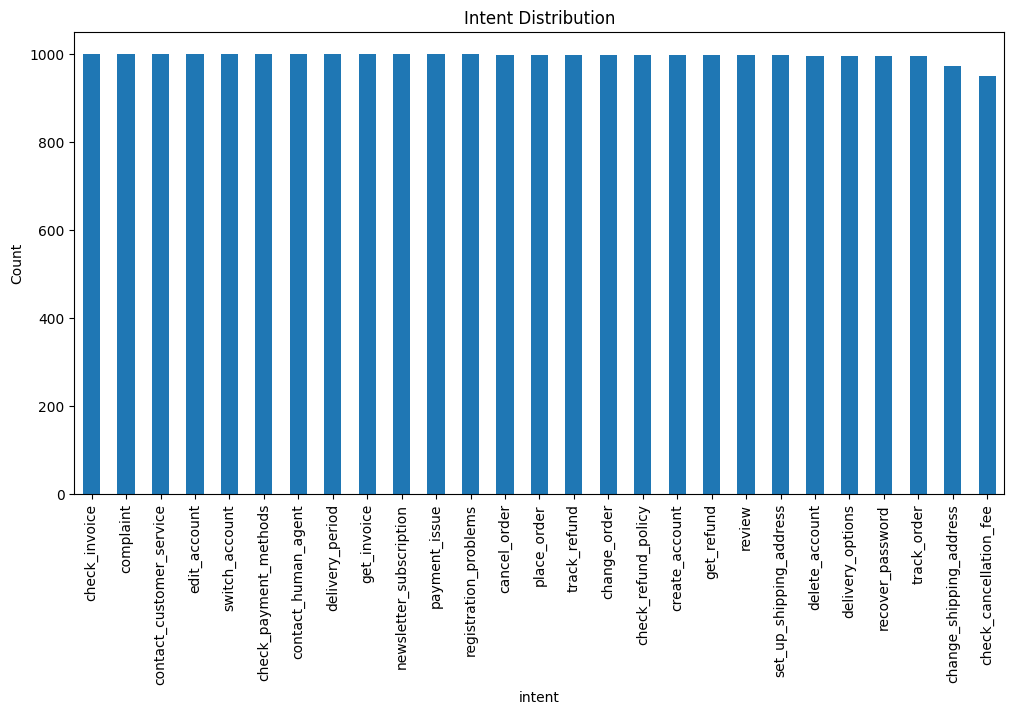

In [10]:
plt.figure(figsize=(12,6))

intent_counts.plot(kind="bar")

plt.title("Intent Distribution")
plt.ylabel("Count")
plt.show()

In [11]:
intent_counts.describe()

count      27.000000
mean      995.259259
std        10.368564
min       950.000000
25%       997.000000
50%       998.000000
75%       999.000000
max      1000.000000
Name: count, dtype: float64

In [12]:
df["prompt_length"] = (
    df["prompt"]
      .str.split()
      .apply(len)
)

df["prompt_length"].describe()

count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: prompt_length, dtype: float64

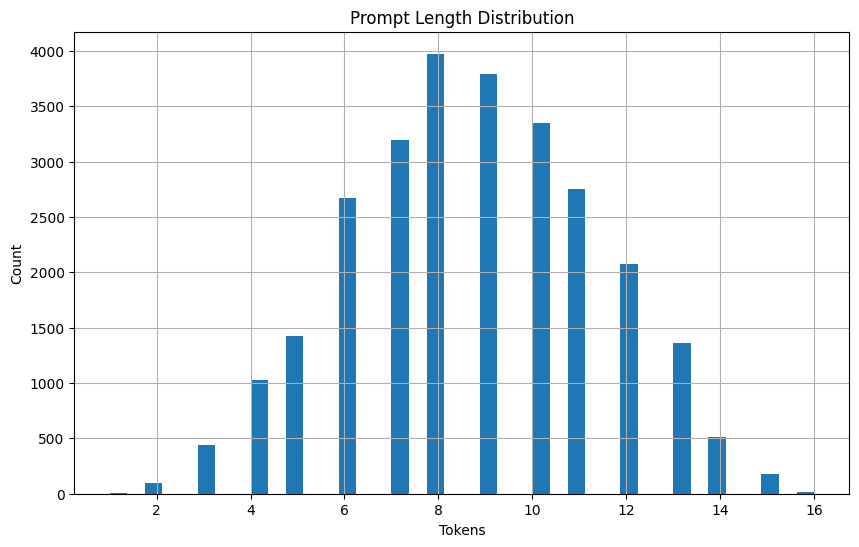

In [13]:
plt.figure(figsize=(10,6))

df["prompt_length"].hist(
    bins=40
)

plt.title("Prompt Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")

plt.show()

In [14]:
df["response_length"] = (
    df["response"]
      .str.split()
      .apply(len)
)

df["response_length"].describe()

count    26872.000000
mean       104.789037
std         52.966204
min          9.000000
25%         72.000000
50%         90.000000
75%        124.000000
max        402.000000
Name: response_length, dtype: float64

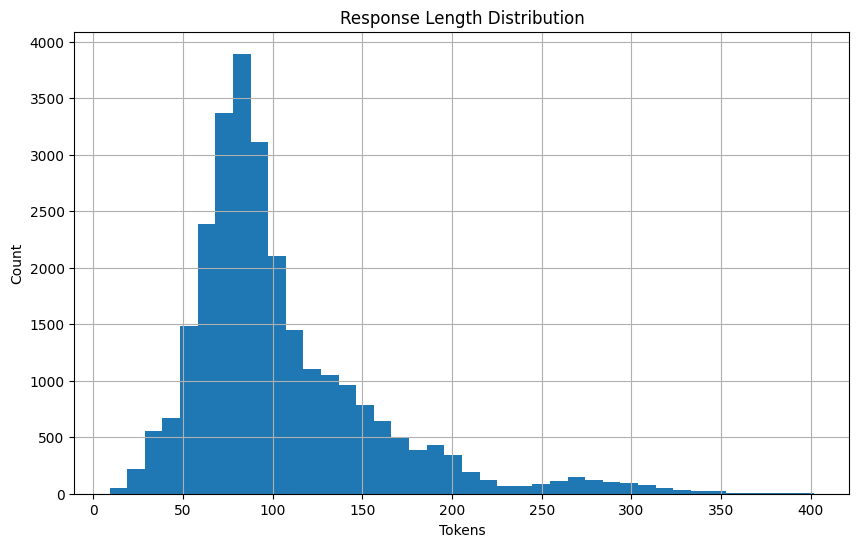

In [15]:
plt.figure(figsize=(10,6))

df["response_length"].hist(
    bins=40
)

plt.title("Response Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")

plt.show()

In [16]:
duplicate_prompts = (
    df["prompt"]
      .duplicated()
      .sum()
)

print(
    "Duplicate prompts:",
    duplicate_prompts
)

Duplicate prompts: 2237


In [17]:
contains_placeholder = (
    df["prompt"]
      .str.contains(
          r"\{\{.*?\}\}",
          regex=True
      )
)

print(
    "Prompts with placeholders:",
    contains_placeholder.sum()
)

print(
    "Percentage:",
    round(
        contains_placeholder.mean()*100,
        2
    ),
    "%"
)

Prompts with placeholders: 6670
Percentage: 24.82 %
